In [1]:
!pip install -q catboost scikit-learn pandas numpy matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 10.1 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.dummy import DummyRegressor
from catboost import CatBoostRegressor

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

RANDOM_STATE = 42

print("Setup complete ")

Setup complete 


In [3]:
from pathlib import Path

DATA_DIR = Path("/content")

for file in DATA_DIR.iterdir():
    print(file.name)

.config
validation-predictions-template.csv
december-chart-inputs.csv
validation.csv
score.py
train-test.csv
sample_data


In [4]:
train_df = pd.read_csv("/content/train-test.csv")
validation_df = pd.read_csv("/content/validation.csv")
template_df = pd.read_csv("/content/validation-predictions-template.csv")
december_df = pd.read_csv("/content/december-chart-inputs.csv")

print("Train:", train_df.shape)
print("Validation:", validation_df.shape)
print("Template:", template_df.shape)
print("December:", december_df.shape)

Train: (48000, 14)
Validation: (12000, 13)
Template: (12000, 2)
December: (31, 7)


In [5]:
print("=" * 60)
print("TRAIN DATA")
print("=" * 60)

display(train_df.head())

print("\nShape:", train_df.shape)

print("\nColumns:")
print(train_df.columns.tolist())

print("\nData types:")
print(train_df.dtypes)

print("\nMissing values:")
display(
    train_df.isna()
    .sum()
    .sort_values(ascending=False)
    .to_frame("missing_count")
)

print("\nDuplicate rows:", train_df.duplicated().sum())

print("\nDuplicate load IDs:", train_df["load_id"].duplicated().sum())

print("\nTarget statistics:")
display(train_df["posted_rate"].describe())

TRAIN DATA


,load_id,pickup,delivery,pickup_lat,pickup_lon,delivery_lat,delivery_lon,distance,equipment,weight,date,market_index,quote_signal,posted_rate
0,TR-000001,Richmond,Baltimore,38.09122,-76.78906,38.16908,-72.74564,274.3,Dry Van,30658.0,2025-01-01,0.95684,2.39595,645.41
1,TR-000002,Richmond,Philadelphia,38.09122,-76.78906,39.22317,-72.96710,280.5,Reefer,17555.0,2025-01-01,0.97623,2.43355,679.97
2,TR-000003,Philadelphia,Green Bay,39.22317,-72.96710,44.30296,-87.52871,967.8,Dry Van,31721.0,2025-01-01,1.00971,1.84491,1802.54
3,TR-000004,Hartford,Atlanta,39.55328,-72.18051,34.84933,-86.28940,965.4,Dry Van,32333.0,2025-01-01,0.94518,1.87712,1827.28
4,TR-000005,Dallas,Nashville,31.83025,-94.38343,35.29479,-88.08915,541.9,Reefer,35183.0,2025-01-01,0.98480,2.56300,1380.28



Shape: (48000, 14)

Columns:
['load_id', 'pickup', 'delivery', 'pickup_lat', 'pickup_lon', 'delivery_lat', 'delivery_lon', 'distance', 'equipment', 'weight', 'date', 'market_index', 'quote_signal', 'posted_rate']

Data types:
load_id          object
pickup           object
delivery         object
pickup_lat      float64
pickup_lon      float64
delivery_lat    float64
delivery_lon    float64
distance        float64
equipment        object
weight          float64
date             object
market_index    float64
quote_signal    float64
posted_rate     float64
dtype: object

Missing values:


,missing_count
market_index,374
weight,300
delivery,0
pickup_lat,0
load_id,0
pickup,0
delivery_lat,0
pickup_lon,0
distance,0
delivery_lon,0



Duplicate rows: 0

Duplicate load IDs: 0

Target statistics:


,posted_rate
count,48000.000000
mean,2373.980682
std,1486.493245
min,57.220000
25%,1251.555000
50%,2030.760000
75%,3330.750000
max,25533.000000


In [6]:
train_df["date"] = pd.to_datetime(train_df["date"])
validation_df["date"] = pd.to_datetime(validation_df["date"])
december_df["date"] = pd.to_datetime(december_df["date"])

print("Training date range:")
print(train_df["date"].min(), "→", train_df["date"].max())

print("\nFinal validation date range:")
print(validation_df["date"].min(), "→", validation_df["date"].max())

print("\nDecember chart range:")
print(december_df["date"].min(), "→", december_df["date"].max())

Training date range:
2025-01-01 00:00:00 → 2025-10-31 00:00:00

Final validation date range:
2025-11-01 00:00:00 → 2025-12-31 00:00:00

December chart range:
2025-12-01 00:00:00 → 2025-12-31 00:00:00


In [7]:
def data_quality_report(df, name):
    print(f"\n{'='*60}")
    print(name)
    print("="*60)

    report = pd.DataFrame({
        "dtype": df.dtypes.astype(str),
        "missing": df.isna().sum(),
        "missing_%": (df.isna().mean() * 100).round(2),
        "unique": df.nunique()
    })

    display(report)

data_quality_report(train_df, "TRAIN")
data_quality_report(validation_df, "FINAL VALIDATION")


TRAIN


,dtype,missing,missing_%,unique
load_id,object,0,0.00,48000
pickup,object,0,0.00,64
delivery,object,0,0.00,64
pickup_lat,float64,0,0.00,64
pickup_lon,float64,0,0.00,63
delivery_lat,float64,0,0.00,64
delivery_lon,float64,0,0.00,63
distance,float64,0,0.00,21204
equipment,object,0,0.00,3
weight,float64,300,0.62,23678



FINAL VALIDATION


,dtype,missing,missing_%,unique
load_id,object,0,0.00,12000
pickup,object,0,0.00,72
delivery,object,0,0.00,72
pickup_lat,float64,0,0.00,72
pickup_lon,float64,0,0.00,71
delivery_lat,float64,0,0.00,72
delivery_lon,float64,0,0.00,71
distance,float64,0,0.00,9309
equipment,object,0,0.00,3
weight,float64,165,1.38,9472


In [8]:
numeric_cols = [
    "pickup_lat",
    "pickup_lon",
    "delivery_lat",
    "delivery_lon",
    "distance",
    "weight",
    "market_index",
    "quote_signal",
    "posted_rate"
]

display(train_df[numeric_cols].describe().T)

print("Negative distance:", (train_df["distance"] < 0).sum())
print("Zero distance:", (train_df["distance"] == 0).sum())

print("Negative weight:", (train_df["weight"] < 0).sum())
print("Zero weight:", (train_df["weight"] == 0).sum())

print("Non-positive posted rate:", (train_df["posted_rate"] <= 0).sum())

,count,mean,std,min,25%,50%,75%,max
pickup_lat,48000.0,35.647545,4.315285,28.35765,31.98691,35.29479,39.411040,44.30296
pickup_lon,48000.0,-90.928964,13.482431,-121.69849,-98.40059,-88.08915,-83.285060,-69.50000
delivery_lat,48000.0,35.641175,4.317199,28.35765,31.98691,35.29479,39.411040,44.30296
delivery_lon,48000.0,-90.857310,13.476589,-121.69849,-98.40059,-87.52871,-83.285060,-69.50000
distance,48000.0,1135.856654,728.564416,70.00000,550.40000,953.30000,1645.525000,3439.80000
weight,47700.0,31028.844004,9391.440620,-47500.00000,25800.00000,31436.50000,37018.000000,47500.00000
market_index,47626.0,1.083387,0.168091,0.67639,0.94967,1.05580,1.219590,1.46778
quote_signal,48000.0,2.062468,0.291391,0.69228,1.89103,2.05575,2.221685,3.61035
posted_rate,48000.0,2373.980682,1486.493245,57.22000,1251.55500,2030.76000,3330.750000,25533.00000


Negative distance: 0
Zero distance: 0
Negative weight: 292
Zero weight: 0
Non-positive posted rate: 0


In [9]:
negative_weights = train_df[train_df["weight"] < 0].copy()

print("Negative weight rows:", len(negative_weights))

print("\nNegative weight statistics:")
display(negative_weights["weight"].describe())

print("\nSample negative-weight rows:")
display(
    negative_weights[
        [
            "load_id",
            "pickup",
            "delivery",
            "distance",
            "equipment",
            "weight",
            "market_index",
            "quote_signal",
            "posted_rate"
        ]
    ].head(20)
)

print("\nAbsolute negative weight distribution:")
display(negative_weights["weight"].abs().describe())

print("\nNormal positive weight distribution:")
display(
    train_df.loc[train_df["weight"] > 0, "weight"].describe()
)

Negative weight rows: 292

Negative weight statistics:


,weight
count,292.000000
mean,-31724.195205
std,8262.536326
min,-47500.000000
25%,-37284.250000
50%,-31821.500000
75%,-25928.500000
max,-5000.000000



Sample negative-weight rows:


,load_id,pickup,delivery,distance,equipment,weight,market_index,quote_signal,posted_rate
68,TR-000069,Amarillo,Dayton,1334.2,Reefer,-36559.0,0.96102,2.11777,2831.27
204,TR-000205,Fresno,Tucson,496.2,Dry Van,-26670.0,0.96903,2.13155,1046.92
206,TR-000207,Columbia,Raleigh,411.3,Reefer,-20003.0,0.94800,2.31682,959.15
225,TR-000226,Greensboro,Lubbock,1317.4,Reefer,-23981.0,1.00820,2.13918,2836.00
376,TR-000377,Madison,Providence,1331.1,Dry Van,-41397.0,0.94787,1.91867,2522.54
446,TR-000447,Albuquerque,Albany,2438.3,Reefer,-37215.0,0.96575,1.96959,4841.57
495,TR-000496,Montgomery,Dayton,715.9,Dry Van,-31214.0,0.85153,2.03947,1473.78
641,TR-000642,Tulsa,Indianapolis,582.4,Dry Van,-41023.0,0.81988,2.22721,1264.33
806,TR-000807,Cincinnati,Buffalo,676.1,Dry Van,-28320.0,0.79158,1.95680,1307.76
1093,TR-001094,Cincinnati,Albany,1058.5,Dry Van,-25153.0,0.89891,1.81081,1907.83



Absolute negative weight distribution:


,weight
count,292.000000
mean,31724.195205
std,8262.536326
min,5000.000000
25%,25928.500000
50%,31821.500000
75%,37284.250000
max,47500.000000



Normal positive weight distribution:


,weight
count,47408.000000
mean,31415.358674
std,7994.902979
min,5000.000000
25%,25922.000000
50%,31493.500000
75%,37063.000000
max,47500.000000


In [10]:
print("TRAIN")
print("Missing weight:", train_df["weight"].isna().sum())
print("Negative weight:", (train_df["weight"] < 0).sum())

print("\nFINAL VALIDATION")
print("Missing weight:", validation_df["weight"].isna().sum())
print("Negative weight:", (validation_df["weight"] < 0).sum())

print("\nMissing market_index:")
print("Train:", train_df["market_index"].isna().sum())
print("Validation:", validation_df["market_index"].isna().sum())

TRAIN
Missing weight: 300
Negative weight: 292

FINAL VALIDATION
Missing weight: 165
Negative weight: 145

Missing market_index:
Train: 374
Validation: 249


In [11]:
corr_cols = [
    "distance",
    "weight",
    "market_index",
    "quote_signal",
    "posted_rate"
]

corr = train_df[corr_cols].corr(numeric_only=True)

display(corr.round(3))

print("\nCorrelation with posted_rate:")
display(
    corr["posted_rate"]
    .drop("posted_rate")
    .sort_values(ascending=False)
    .to_frame("correlation")
)

,distance,weight,market_index,quote_signal,posted_rate
distance,1.000,0.003,-0.002,-0.057,0.909
weight,0.003,1.000,-0.001,0.008,0.035
market_index,-0.002,-0.001,1.000,-0.068,0.034
quote_signal,-0.057,0.008,-0.068,1.000,-0.040
posted_rate,0.909,0.035,0.034,-0.040,1.000



Correlation with posted_rate:


,correlation
distance,0.908519
weight,0.034840
market_index,0.034165
quote_signal,-0.039858


In [12]:
eda_df = train_df.copy()

eda_df["rate_per_mile"] = (
    eda_df["posted_rate"] / eda_df["distance"]
)

display(
    eda_df[
        [
            "posted_rate",
            "distance",
            "rate_per_mile",
            "market_index",
            "quote_signal"
        ]
    ].describe()
)

,posted_rate,distance,rate_per_mile,market_index,quote_signal
count,48000.000000,48000.000000,48000.000000,47626.000000,48000.000000
mean,2373.980682,1135.856654,2.215347,1.083387,2.062468
std,1486.493245,728.564416,0.583887,0.168091,0.291391
min,57.220000,70.000000,0.333709,0.676390,0.692280
25%,1251.555000,550.400000,1.986974,0.949670,1.891030
50%,2030.760000,953.300000,2.145348,1.055800,2.055750
75%,3330.750000,1645.525000,2.342696,1.219590,2.221685
max,25533.000000,3439.800000,14.125294,1.467780,3.610350


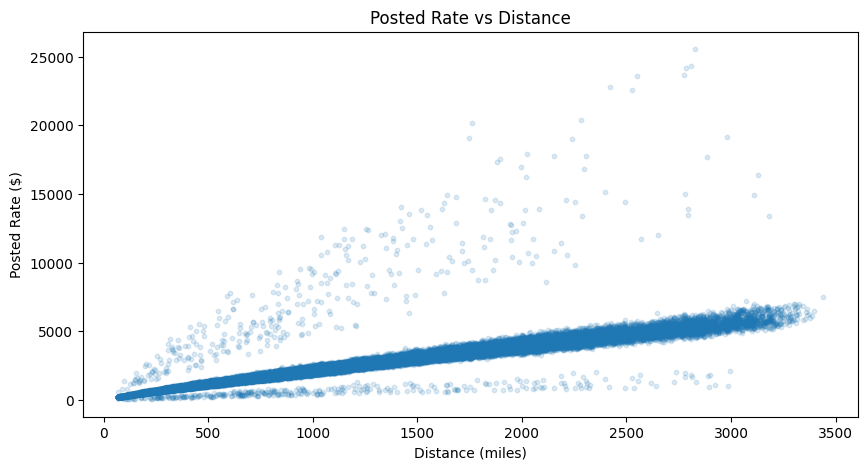

In [13]:
plt.figure(figsize=(10, 5))

plt.scatter(
    train_df["distance"],
    train_df["posted_rate"],
    alpha=0.15,
    s=10
)

plt.xlabel("Distance (miles)")
plt.ylabel("Posted Rate ($)")
plt.title("Posted Rate vs Distance")
plt.show()

In [14]:
equipment_summary = (
    train_df
    .groupby("equipment")
    .agg(
        loads=("load_id", "count"),
        avg_rate=("posted_rate", "mean"),
        median_rate=("posted_rate", "median"),
        avg_distance=("distance", "mean"),
        avg_weight=("weight", "mean")
    )
    .sort_values("avg_rate", ascending=False)
)

display(equipment_summary.round(2))

,loads,avg_rate,median_rate,avg_distance,avg_weight
equipment,,,,,
Reefer,12045,2553.64,2196.67,1135.07,31079.71
Flatbed,8753,2445.09,2076.81,1132.51,30963.63
Dry Van,27202,2271.55,1953.04,1137.28,31027.29


In [15]:
display(
    train_df.nlargest(
        20,
        "posted_rate"
    )[
        [
            "load_id",
            "pickup",
            "delivery",
            "distance",
            "equipment",
            "weight",
            "market_index",
            "quote_signal",
            "date",
            "posted_rate"
        ]
    ]
)

,load_id,pickup,delivery,distance,equipment,weight,market_index,quote_signal,date,posted_rate
12184,TR-012185,Bakersfield,Hartford,2829.8,Dry Van,33153.0,1.16556,1.83188,2025-03-19,25533.00
37764,TR-037765,Phoenix,Syracuse,2810.9,Dry Van,33674.0,1.04877,2.16284,2025-08-27,24294.98
1466,TR-001467,Los Angeles,Syracuse,2786.0,Reefer,30322.0,0.98678,1.85370,2025-01-10,24140.21
17371,TR-017372,Reno,Philadelphia,2777.6,Reefer,33158.0,1.15070,2.15601,2025-04-20,23662.71
26235,TR-026236,Charleston,Phoenix,2552.5,Dry Van,25665.0,1.20224,1.81289,2025-06-15,23580.42
28219,TR-028220,Tucson,Raleigh,2423.3,Dry Van,30972.0,1.32894,1.97112,2025-06-27,22755.66
3353,TR-003354,Phoenix,Charleston,2527.9,Reefer,36840.0,1.03241,2.07342,2025-01-22,22534.65
40171,TR-040172,Montgomery,Fresno,2283.4,Dry Van,32447.0,0.98502,1.93645,2025-09-11,20361.89
40096,TR-040097,Baltimore,Oklahoma City,1760.3,Reefer,29521.0,1.00464,2.28753,2025-09-11,20132.37
47298,TR-047299,Boston,Bakersfield,2979.1,Reefer,30585.0,0.86501,2.09472,2025-10-27,19110.30


In [16]:
q1 = train_df["posted_rate"].quantile(0.25)
q3 = train_df["posted_rate"].quantile(0.75)

iqr = q3 - q1
upper_bound = q3 + 1.5 * iqr

print("Q1:", round(q1, 2))
print("Q3:", round(q3, 2))
print("IQR:", round(iqr, 2))
print("IQR upper bound:", round(upper_bound, 2))

print(
    "Rows above IQR upper bound:",
    (train_df["posted_rate"] > upper_bound).sum()
)

print(
    "Percentage:",
    round(
        (train_df["posted_rate"] > upper_bound).mean() * 100,
        2
    ),
    "%"
)

Q1: 1251.55
Q3: 3330.75
IQR: 2079.2
IQR upper bound: 6449.54
Rows above IQR upper bound: 260
Percentage: 0.54 %


In [17]:
for col in ["pickup", "delivery", "equipment"]:

    train_values = set(
        train_df[col].dropna().unique()
    )

    validation_values = set(
        validation_df[col].dropna().unique()
    )

    unseen = validation_values - train_values

    print(f"\n{col}")
    print("Train unique:", len(train_values))
    print("Validation unique:", len(validation_values))
    print("Unseen in training:", len(unseen))

    if unseen:
        print(sorted(unseen))


pickup
Train unique: 64
Validation unique: 72
Unseen in training: 8
['Allentown', 'Charlotte', 'Chicago', 'Jackson', 'Knoxville', 'Laredo', 'Norfolk', 'San Diego']

delivery
Train unique: 64
Validation unique: 72
Unseen in training: 8
['Allentown', 'Charlotte', 'Chicago', 'Jackson', 'Knoxville', 'Laredo', 'Norfolk', 'San Diego']

equipment
Train unique: 3
Validation unique: 3
Unseen in training: 0


In [18]:
monthly = (
    train_df
    .assign(month=train_df["date"].dt.to_period("M"))
    .groupby("month")
    .agg(
        loads=("load_id", "count"),
        avg_rate=("posted_rate", "mean"),
        median_rate=("posted_rate", "median"),
        avg_market_index=("market_index", "mean"),
        avg_quote_signal=("quote_signal", "mean")
    )
)

display(monthly.round(2))

,loads,avg_rate,median_rate,avg_market_index,avg_quote_signal
month,,,,,
2025-01,4918,2255.97,1915.20,0.93,2.07
2025-02,4337,2273.80,1994.25,1.00,2.10
2025-03,5036,2372.27,2022.92,1.07,2.18
2025-04,4819,2372.16,2044.24,1.21,1.96
2025-05,4913,2421.78,2065.51,1.30,1.91
2025-06,4783,2497.03,2120.22,1.28,2.30
2025-07,4912,2415.16,2059.14,1.20,1.92
2025-08,4759,2338.41,2015.73,0.98,2.05
2025-09,4670,2406.37,2057.13,0.89,2.20


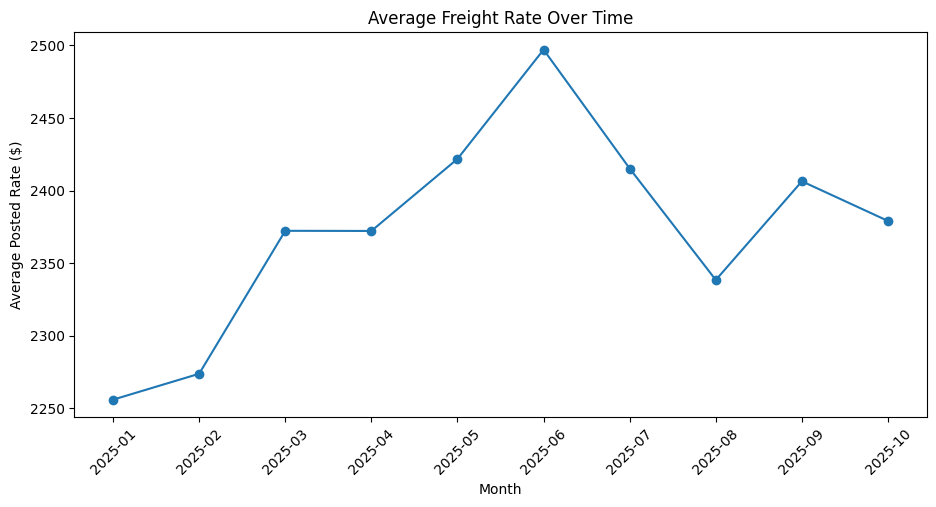

In [19]:
monthly_plot = monthly.copy()
monthly_plot.index = monthly_plot.index.astype(str)

plt.figure(figsize=(11, 5))
plt.plot(
    monthly_plot.index,
    monthly_plot["avg_rate"],
    marker="o"
)

plt.xlabel("Month")
plt.ylabel("Average Posted Rate ($)")
plt.title("Average Freight Rate Over Time")
plt.xticks(rotation=45)
plt.show()

In [20]:
def prepare_features(df):
    df = df.copy()


    df["date"] = pd.to_datetime(df["date"])

    df["weight"] = df["weight"].abs()


    df["weight_missing"] = df["weight"].isna().astype(int)
    df["market_index_missing"] = df["market_index"].isna().astype(int)

    df["weight"] = df["weight"].fillna(train_df["weight"].abs().median())
    df["market_index"] = df["market_index"].fillna(
        train_df["market_index"].median()
    )

    # Date features
    df["month"] = df["date"].dt.month
    df["day"] = df["date"].dt.day
    df["day_of_week"] = df["date"].dt.dayofweek
    df["day_of_year"] = df["date"].dt.dayofyear
    df["week_of_year"] = df["date"].dt.isocalendar().week.astype(int)
    df["is_weekend"] = (df["day_of_week"] >= 5).astype(int)

    # Continuous time trend
    origin = pd.Timestamp("2025-01-01")
    df["days_since_start"] = (df["date"] - origin).dt.days

    # Geographic features
    df["lat_diff"] = df["delivery_lat"] - df["pickup_lat"]
    df["lon_diff"] = df["delivery_lon"] - df["pickup_lon"]

    # Interaction features
    df["distance_market"] = df["distance"] * df["market_index"]
    df["distance_quote"] = df["distance"] * df["quote_signal"]

    return df


prepared_train = prepare_features(train_df)

print("Prepared shape:", prepared_train.shape)
display(prepared_train.head())

Prepared shape: (48000, 27)


,load_id,pickup,delivery,pickup_lat,pickup_lon,delivery_lat,delivery_lon,distance,equipment,weight,date,market_index,quote_signal,posted_rate,weight_missing,market_index_missing,month,day,day_of_week,day_of_year,week_of_year,is_weekend,days_since_start,lat_diff,lon_diff,distance_market,distance_quote
0,TR-000001,Richmond,Baltimore,38.09122,-76.78906,38.16908,-72.74564,274.3,Dry Van,30658.0,2025-01-01,0.95684,2.39595,645.41,0,0,1,1,2,1,1,0,0,0.07786,4.04342,262.461212,657.209085
1,TR-000002,Richmond,Philadelphia,38.09122,-76.78906,39.22317,-72.96710,280.5,Reefer,17555.0,2025-01-01,0.97623,2.43355,679.97,0,0,1,1,2,1,1,0,0,1.13195,3.82196,273.832515,682.610775
2,TR-000003,Philadelphia,Green Bay,39.22317,-72.96710,44.30296,-87.52871,967.8,Dry Van,31721.0,2025-01-01,1.00971,1.84491,1802.54,0,0,1,1,2,1,1,0,0,5.07979,-14.56161,977.197338,1785.503898
3,TR-000004,Hartford,Atlanta,39.55328,-72.18051,34.84933,-86.28940,965.4,Dry Van,32333.0,2025-01-01,0.94518,1.87712,1827.28,0,0,1,1,2,1,1,0,0,-4.70395,-14.10889,912.476772,1812.171648
4,TR-000005,Dallas,Nashville,31.83025,-94.38343,35.29479,-88.08915,541.9,Reefer,35183.0,2025-01-01,0.98480,2.56300,1380.28,0,0,1,1,2,1,1,0,0,3.46454,6.29428,533.663120,1388.889700


In [21]:
cutoff_date = pd.Timestamp("2025-10-01")

dev_train = prepared_train[
    prepared_train["date"] < cutoff_date
].copy()

dev_valid = prepared_train[
    prepared_train["date"] >= cutoff_date
].copy()

print("Development Train:")
print(dev_train["date"].min(), "→", dev_train["date"].max())
print("Rows:", len(dev_train))

print("\nInternal Validation:")
print(dev_valid["date"].min(), "→", dev_valid["date"].max())
print("Rows:", len(dev_valid))

Development Train:
2025-01-01 00:00:00 → 2025-09-30 00:00:00
Rows: 43147

Internal Validation:
2025-10-01 00:00:00 → 2025-10-31 00:00:00
Rows: 4853


In [22]:
TARGET = "posted_rate"

FEATURES = [
    # Categorical
    "pickup",
    "delivery",
    "equipment",

    # Geography
    "pickup_lat",
    "pickup_lon",
    "delivery_lat",
    "delivery_lon",
    "lat_diff",
    "lon_diff",

    # Load
    "distance",
    "weight",

    # Market
    "market_index",
    "quote_signal",

    # Missingness
    "weight_missing",
    "market_index_missing",

    # Time
    "month",
    "day",
    "day_of_week",
    "day_of_year",
    "week_of_year",
    "is_weekend",
    "days_since_start",

    # Interactions
    "distance_market",
    "distance_quote"
]

CAT_FEATURES = [
    "pickup",
    "delivery",
    "equipment"
]

X_train = dev_train[FEATURES]
y_train = dev_train[TARGET]

X_valid = dev_valid[FEATURES]
y_valid = dev_valid[TARGET]

print("Train:", X_train.shape)
print("Validation:", X_valid.shape)
print("Features:", len(FEATURES))

Train: (43147, 24)
Validation: (4853, 24)
Features: 24


In [23]:
baseline_prediction = np.repeat(
    y_train.median(),
    len(y_valid)
)

baseline_mae = mean_absolute_error(
    y_valid,
    baseline_prediction
)

baseline_rmse = np.sqrt(
    mean_squared_error(
        y_valid,
        baseline_prediction
    )
)

baseline_r2 = r2_score(
    y_valid,
    baseline_prediction
)

print("BASELINE")
print(f"MAE : ${baseline_mae:,.2f}")
print(f"RMSE: ${baseline_rmse:,.2f}")
print(f"R²  : {baseline_r2:.4f}")

BASELINE
MAE : $1,146.79
RMSE: $1,567.97
R²  : -0.0522


In [24]:
model = CatBoostRegressor(
    iterations=1500,
    learning_rate=0.04,
    depth=8,

    loss_function="RMSE",
    eval_metric="MAE",

    random_seed=RANDOM_STATE,

    l2_leaf_reg=5,

    verbose=100,
    allow_writing_files=False
)

model.fit(
    X_train,
    y_train,

    cat_features=CAT_FEATURES,

    eval_set=(X_valid, y_valid),

    early_stopping_rounds=150,
    verbose=100
)

0:	learn: 1116.8541258	test: 1135.9831186	best: 1135.9831186 (0)	total: 107ms	remaining: 2m 39s
100:	learn: 120.8563262	test: 142.7478326	best: 142.7478326 (100)	total: 5.76s	remaining: 1m 19s
200:	learn: 105.8268872	test: 141.2440550	best: 136.2171107 (135)	total: 9.44s	remaining: 1m 1s
Stopped by overfitting detector  (150 iterations wait)

bestTest = 136.2171107
bestIteration = 135

Shrink model to first 136 iterations.


CatBoostRegressor(allow_writing_files=False, depth=8, eval_metric='MAE', iterations=1500, l2_leaf_reg=5, learning_rate=0.04, loss_function='RMSE', random_seed=42, verbose=100)

In [25]:
valid_pred = model.predict(X_valid)

mae = mean_absolute_error(
    y_valid,
    valid_pred
)

rmse = np.sqrt(
    mean_squared_error(
        y_valid,
        valid_pred
    )
)

r2 = r2_score(
    y_valid,
    valid_pred
)

mape = np.mean(
    np.abs(
        (y_valid.values - valid_pred) /
        y_valid.values
    )
) * 100

print("=" * 45)
print("CATBOOST - OCTOBER HOLDOUT")
print("=" * 45)

print(f"MAE : ${mae:,.2f}")
print(f"RMSE: ${rmse:,.2f}")
print(f"R²  : {r2:.4f}")
print(f"MAPE: {mape:.2f}%")

print("\nImprovement over median baseline:")
print(
    f"MAE reduction: "
    f"{((baseline_mae-mae)/baseline_mae)*100:.2f}%"
)

CATBOOST - OCTOBER HOLDOUT
MAE : $136.22
RMSE: $650.69
R²  : 0.8188
MAPE: 7.88%

Improvement over median baseline:
MAE reduction: 88.12%


,feature,importance
9,distance,46.210349
23,distance_quote,29.327394
22,distance_market,12.926969
2,equipment,4.467879
12,quote_signal,1.612581
10,weight,1.354108
8,lon_diff,0.512243
19,week_of_year,0.426951
5,delivery_lat,0.368631
4,pickup_lon,0.366869


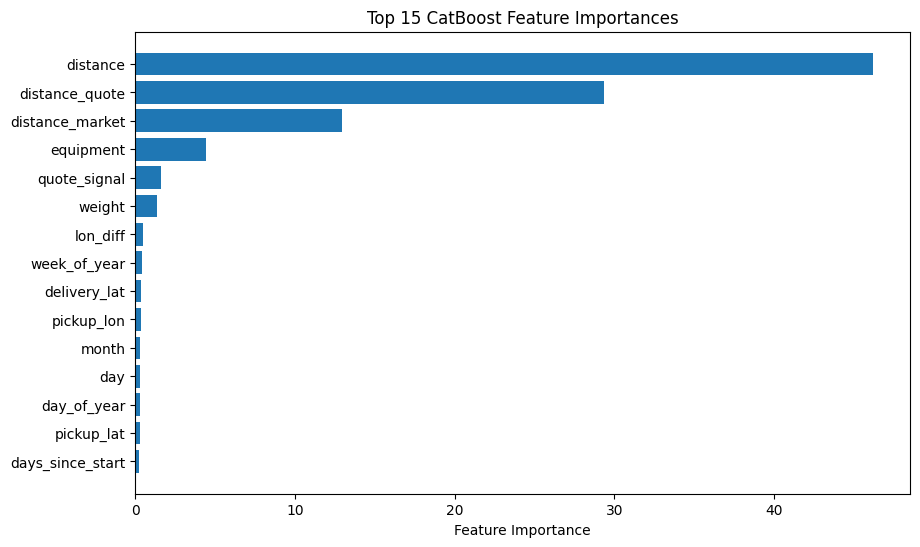

In [26]:
importance = pd.DataFrame({
    "feature": FEATURES,
    "importance": model.get_feature_importance()
}).sort_values(
    "importance",
    ascending=False
)

display(importance.head(15))

plt.figure(figsize=(10, 6))

top = importance.head(15).sort_values("importance")

plt.barh(
    top["feature"],
    top["importance"]
)

plt.xlabel("Feature Importance")
plt.title("Top 15 CatBoost Feature Importances")
plt.show()

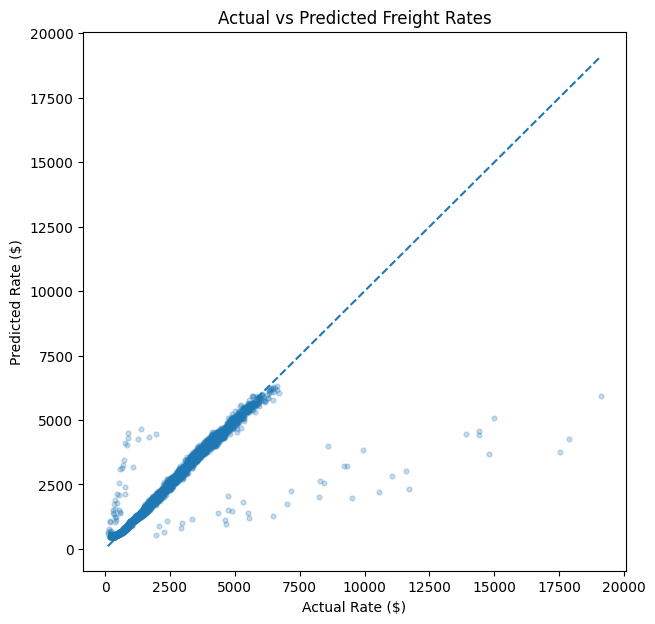

In [27]:
plt.figure(figsize=(7, 7))

plt.scatter(
    y_valid,
    valid_pred,
    alpha=0.25,
    s=12
)

minimum = min(y_valid.min(), valid_pred.min())
maximum = max(y_valid.max(), valid_pred.max())

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    "--"
)

plt.xlabel("Actual Rate ($)")
plt.ylabel("Predicted Rate ($)")
plt.title("Actual vs Predicted Freight Rates")
plt.show()

In [28]:
error_df = dev_valid[
    [
        "load_id",
        "pickup",
        "delivery",
        "distance",
        "equipment",
        "weight",
        "posted_rate"
    ]
].copy()

error_df["predicted_rate"] = valid_pred

error_df["absolute_error"] = np.abs(
    error_df["posted_rate"] -
    error_df["predicted_rate"]
)

error_df["percentage_error"] = (
    error_df["absolute_error"] /
    error_df["posted_rate"]
) * 100

display(
    error_df
    .sort_values(
        "absolute_error",
        ascending=False
    )
    .head(20)
)

,load_id,pickup,delivery,distance,equipment,weight,posted_rate,predicted_rate,absolute_error,percentage_error
43539,TR-043540,Milwaukee,Bakersfield,1893.0,Dry Van,30760.0,17514.11,3773.556644,13740.553356,78.454191
46213,TR-046214,Columbia,Tucson,2023.4,Flatbed,34710.0,17893.17,4262.704756,13630.465244,76.176917
47298,TR-047299,Boston,Bakersfield,2979.1,Reefer,30585.0,19110.30,5916.011471,13194.288529,69.042812
46516,TR-046517,Toledo,Albuquerque,1684.3,Reefer,31536.0,14784.38,3691.283952,11093.096048,75.032541
46366,TR-046367,Bakersfield,Columbia,2251.9,Dry Van,40729.0,14403.14,4416.039828,9987.100172,69.339742
47536,TR-047537,Los Angeles,Richmond,2782.4,Dry Van,25730.0,15003.55,5097.038290,9906.511710,66.027785
44267,TR-044268,Albany,Albuquerque,2492.6,Dry Van,25513.0,14425.42,4557.494381,9867.925619,68.406505
43302,TR-043303,Atlanta,Phoenix,2083.1,Reefer,40335.0,13894.55,4443.229564,9451.320436,68.021781
43384,TR-043385,Lexington,Lubbock,1187.0,Dry Van,25359.0,11696.44,2333.586802,9362.853198,80.048743
47586,TR-047587,Corpus Christi,Las Vegas,1383.3,Flatbed,18645.0,11596.28,3020.159842,8576.120158,73.955787


In [29]:
abs_errors = np.abs(y_valid.values - valid_pred)

print("ERROR DISTRIBUTION")
print("=" * 45)

for p in [50, 75, 90, 95, 99, 100]:
    print(
        f"P{p:>3}: ${np.percentile(abs_errors, p):,.2f}"
    )

print("\nLarge errors:")
print(">$500 :", (abs_errors > 500).sum())
print(">$1000:", (abs_errors > 1000).sum())
print(">$2000:", (abs_errors > 2000).sum())

ERROR DISTRIBUTION
P 50: $56.94
P 75: $109.83
P 90: $182.38
P 95: $245.43
P 99: $1,819.81
P100: $13,740.55

Large errors:
>$500 : 80
>$1000: 64
>$2000: 47


In [30]:
analysis = error_df.copy()

analysis["actual_rate"] = analysis["posted_rate"]

analysis["error_bucket"] = pd.cut(
    analysis["actual_rate"],
    bins=[0, 1000, 2000, 3000, 5000, 10000, np.inf],
    labels=[
        "$0-1k",
        "$1k-2k",
        "$2k-3k",
        "$3k-5k",
        "$5k-10k",
        "$10k+"
    ]
)

bucket_results = (
    analysis
    .groupby("error_bucket", observed=True)
    .agg(
        rows=("load_id", "count"),
        avg_actual=("actual_rate", "mean"),
        MAE=("absolute_error", "mean"),
        median_error=("absolute_error", "median")
    )
)

display(bucket_results.round(2))

,rows,avg_actual,MAE,median_error
error_bucket,,,,
$0-1k,805,691.98,119.26,38.09
$1k-2k,1571,1483.83,61.94,43.90
$2k-3k,1056,2439.13,80.48,60.69
$3k-5k,1163,3890.29,128.56,95.00
$5k-10k,246,5631.43,438.40,121.18
$10k+,12,14328.36,10450.43,9887.22


In [31]:
extreme_cases = error_df[
    error_df["posted_rate"] >= 10000
].copy()

extreme_cases["predicted_rate"] = valid_pred[
    y_valid.values >= 10000
]

extreme_cases["absolute_error"] = np.abs(
    extreme_cases["posted_rate"] -
    extreme_cases["predicted_rate"]
)

display(
    extreme_cases.sort_values(
        "posted_rate",
        ascending=False
    )
)

,load_id,pickup,delivery,distance,equipment,weight,posted_rate,predicted_rate,absolute_error,percentage_error
47298,TR-047299,Boston,Bakersfield,2979.1,Reefer,30585.0,19110.30,5916.011471,13194.288529,69.042812
46213,TR-046214,Columbia,Tucson,2023.4,Flatbed,34710.0,17893.17,4262.704756,13630.465244,76.176917
43539,TR-043540,Milwaukee,Bakersfield,1893.0,Dry Van,30760.0,17514.11,3773.556644,13740.553356,78.454191
47536,TR-047537,Los Angeles,Richmond,2782.4,Dry Van,25730.0,15003.55,5097.038290,9906.511710,66.027785
46516,TR-046517,Toledo,Albuquerque,1684.3,Reefer,31536.0,14784.38,3691.283952,11093.096048,75.032541
44267,TR-044268,Albany,Albuquerque,2492.6,Dry Van,25513.0,14425.42,4557.494381,9867.925619,68.406505
46366,TR-046367,Bakersfield,Columbia,2251.9,Dry Van,40729.0,14403.14,4416.039828,9987.100172,69.339742
43302,TR-043303,Atlanta,Phoenix,2083.1,Reefer,40335.0,13894.55,4443.229564,9451.320436,68.021781
43384,TR-043385,Lexington,Lubbock,1187.0,Dry Van,25359.0,11696.44,2333.586802,9362.853198,80.048743
47586,TR-047587,Corpus Christi,Las Vegas,1383.3,Flatbed,18645.0,11596.28,3020.159842,8576.120158,73.955787


In [32]:
extreme_full = dev_valid[
    dev_valid["posted_rate"] >= 10000
][[
    "load_id",
    "pickup",
    "delivery",
    "distance",
    "equipment",
    "weight",
    "market_index",
    "quote_signal",
    "date",
    "posted_rate"
]].copy()

extreme_full["predicted_rate"] = model.predict(
    dev_valid.loc[
        dev_valid["posted_rate"] >= 10000,
        FEATURES
    ]
)

extreme_full["error"] = (
    extreme_full["posted_rate"] -
    extreme_full["predicted_rate"]
)

display(
    extreme_full.sort_values(
        "posted_rate",
        ascending=False
    )
)

,load_id,pickup,delivery,distance,equipment,weight,market_index,quote_signal,date,posted_rate,predicted_rate,error
47298,TR-047299,Boston,Bakersfield,2979.1,Reefer,30585.0,0.86501,2.09472,2025-10-27,19110.30,5916.011471,13194.288529
46213,TR-046214,Columbia,Tucson,2023.4,Flatbed,34710.0,0.89822,2.06797,2025-10-20,17893.17,4262.704756,13630.465244
43539,TR-043540,Milwaukee,Bakersfield,1893.0,Dry Van,30760.0,1.08079,2.22972,2025-10-03,17514.11,3773.556644,13740.553356
47536,TR-047537,Los Angeles,Richmond,2782.4,Dry Van,25730.0,1.03410,2.39203,2025-10-29,15003.55,5097.038290,9906.511710
46516,TR-046517,Toledo,Albuquerque,1684.3,Reefer,31536.0,0.98632,2.05917,2025-10-22,14784.38,3691.283952,11093.096048
44267,TR-044268,Albany,Albuquerque,2492.6,Dry Van,25513.0,1.05590,2.38846,2025-10-08,14425.42,4557.494381,9867.925619
46366,TR-046367,Bakersfield,Columbia,2251.9,Dry Van,40729.0,0.94743,2.19163,2025-10-21,14403.14,4416.039828,9987.100172
43302,TR-043303,Atlanta,Phoenix,2083.1,Reefer,40335.0,0.90740,1.94613,2025-10-01,13894.55,4443.229564,9451.320436
43384,TR-043385,Lexington,Lubbock,1187.0,Dry Van,25359.0,0.95849,2.17408,2025-10-02,11696.44,2333.586802,9362.853198
47586,TR-047587,Corpus Christi,Las Vegas,1383.3,Flatbed,18645.0,1.01713,2.02448,2025-10-29,11596.28,3020.159842,8576.120158


In [33]:
train_extremes = prepared_train[
    prepared_train["posted_rate"] >= 10000
].copy()

print("Total extreme rates:", len(train_extremes))

display(
    train_extremes.groupby(
        train_extremes["date"].dt.to_period("M")
    ).agg(
        extreme_loads=("load_id", "count"),
        avg_rate=("posted_rate", "mean"),
        avg_distance=("distance", "mean"),
        avg_market_index=("market_index", "mean"),
        avg_quote_signal=("quote_signal", "mean")
    ).round(2)
)

Total extreme rates: 103


,extreme_loads,avg_rate,avg_distance,avg_market_index,avg_quote_signal
date,,,,,
2025-01,11,14594.93,2068.48,0.95,1.91
2025-02,3,10532.74,1433.20,0.93,1.96
2025-03,8,13627.18,1713.49,1.07,2.00
2025-04,7,14965.36,2186.91,1.22,2.12
2025-05,10,13563.15,1629.70,1.29,2.05
2025-06,17,13391.14,2008.06,1.28,2.05
2025-07,14,13240.53,1667.65,1.17,2.06
2025-08,9,15187.11,2004.07,1.02,2.09
2025-09,12,13678.50,1878.59,0.89,1.99


In [34]:
display(
    train_extremes[
        [
            "pickup",
            "delivery",
            "equipment",
            "distance",
            "weight",
            "market_index",
            "quote_signal",
            "date",
            "posted_rate"
        ]
    ].sort_values(
        "posted_rate",
        ascending=False
    ).head(50)
)

,pickup,delivery,equipment,distance,weight,market_index,quote_signal,date,posted_rate
12184,Bakersfield,Hartford,Dry Van,2829.8,33153.0,1.16556,1.83188,2025-03-19,25533.00
37764,Phoenix,Syracuse,Dry Van,2810.9,33674.0,1.04877,2.16284,2025-08-27,24294.98
1466,Los Angeles,Syracuse,Reefer,2786.0,30322.0,0.98678,1.85370,2025-01-10,24140.21
17371,Reno,Philadelphia,Reefer,2777.6,33158.0,1.15070,2.15601,2025-04-20,23662.71
26235,Charleston,Phoenix,Dry Van,2552.5,25665.0,1.20224,1.81289,2025-06-15,23580.42
28219,Tucson,Raleigh,Dry Van,2423.3,30972.0,1.32894,1.97112,2025-06-27,22755.66
3353,Phoenix,Charleston,Reefer,2527.9,36840.0,1.03241,2.07342,2025-01-22,22534.65
40171,Montgomery,Fresno,Dry Van,2283.4,32447.0,0.98502,1.93645,2025-09-11,20361.89
40096,Baltimore,Oklahoma City,Reefer,1760.3,29521.0,1.00464,2.28753,2025-09-11,20132.37
47298,Boston,Bakersfield,Reefer,2979.1,30585.0,0.86501,2.09472,2025-10-27,19110.30


In [35]:
def evaluate_model(train_part, valid_part, label):

    X_tr = train_part[FEATURES]
    y_tr = train_part[TARGET]

    X_va = valid_part[FEATURES]
    y_va = valid_part[TARGET]

    m = CatBoostRegressor(
        iterations=1500,
        learning_rate=0.04,
        depth=8,
        loss_function="RMSE",
        eval_metric="MAE",
        random_seed=RANDOM_STATE,
        l2_leaf_reg=5,
        verbose=False,
        allow_writing_files=False
    )

    m.fit(
        X_tr,
        y_tr,
        cat_features=CAT_FEATURES,
        eval_set=(X_va, y_va),
        early_stopping_rounds=150,
        verbose=False
    )

    pred = m.predict(X_va)

    return {
        "validation_period": label,
        "train_rows": len(train_part),
        "valid_rows": len(valid_part),
        "MAE": mean_absolute_error(y_va, pred),
        "RMSE": np.sqrt(mean_squared_error(y_va, pred)),
        "R2": r2_score(y_va, pred)
    }

In [36]:
results = []

for month in [8, 9, 10]:

    valid_start = pd.Timestamp(
        year=2025,
        month=month,
        day=1
    )

    if month == 12:
        valid_end = pd.Timestamp("2026-01-01")
    else:
        valid_end = pd.Timestamp(
            year=2025,
            month=month + 1,
            day=1
        )

    train_part = prepared_train[
        prepared_train["date"] < valid_start
    ].copy()

    valid_part = prepared_train[
        (prepared_train["date"] >= valid_start) &
        (prepared_train["date"] < valid_end)
    ].copy()

    result = evaluate_model(
        train_part,
        valid_part,
        valid_start.strftime("%B")
    )

    results.append(result)

rolling_results = pd.DataFrame(results)

display(
    rolling_results.round(2)
)

print("\nAverage:")
print(
    rolling_results[
        ["MAE", "RMSE", "R2"]
    ].mean().round(2)
)

,validation_period,train_rows,valid_rows,MAE,RMSE,R2
0,August,33718,4759,124.98,617.62,0.82
1,September,38477,4670,118.65,620.50,0.83
2,October,43147,4853,136.22,650.69,0.82



Average:
MAE     126.61
RMSE    629.60
R2        0.83
dtype: float64


In [37]:
mae_model = CatBoostRegressor(
    iterations=1500,
    learning_rate=0.04,
    depth=8,

    loss_function="MAE",
    eval_metric="MAE",

    random_seed=RANDOM_STATE,
    l2_leaf_reg=5,

    verbose=False,
    allow_writing_files=False
)

mae_model.fit(
    X_train,
    y_train,

    cat_features=CAT_FEATURES,

    eval_set=(X_valid, y_valid),

    early_stopping_rounds=150,
    verbose=False
)

mae_pred = mae_model.predict(X_valid)

mae_loss_mae = mean_absolute_error(y_valid, mae_pred)
mae_loss_rmse = np.sqrt(mean_squared_error(y_valid, mae_pred))
mae_loss_r2 = r2_score(y_valid, mae_pred)

comparison = pd.DataFrame({
    "Model": [
        "CatBoost RMSE Loss",
        "CatBoost MAE Loss"
    ],
    "MAE": [
        mae,
        mae_loss_mae
    ],
    "RMSE": [
        rmse,
        mae_loss_rmse
    ],
    "R2": [
        r2,
        mae_loss_r2
    ]
})

display(comparison.round(3))

,Model,MAE,RMSE,R2
0,CatBoost RMSE Loss,136.217,650.695,0.819
1,CatBoost MAE Loss,112.304,645.542,0.822


In [38]:
def evaluate_mae_model(train_part, valid_part, label):

    X_tr = train_part[FEATURES]
    y_tr = train_part[TARGET]

    X_va = valid_part[FEATURES]
    y_va = valid_part[TARGET]

    m = CatBoostRegressor(
        iterations=1500,
        learning_rate=0.04,
        depth=8,
        loss_function="MAE",
        eval_metric="MAE",
        random_seed=RANDOM_STATE,
        l2_leaf_reg=5,
        verbose=False,
        allow_writing_files=False
    )

    m.fit(
        X_tr,
        y_tr,
        cat_features=CAT_FEATURES,
        eval_set=(X_va, y_va),
        early_stopping_rounds=150,
        verbose=False
    )

    pred = m.predict(X_va)

    return {
        "validation_period": label,
        "MAE": mean_absolute_error(y_va, pred),
        "RMSE": np.sqrt(mean_squared_error(y_va, pred)),
        "R2": r2_score(y_va, pred),
        "best_iteration": m.get_best_iteration()
    }


mae_rolling_results = []

for month in [8, 9, 10]:

    valid_start = pd.Timestamp(2025, month, 1)

    valid_end = (
        pd.Timestamp(2025, month + 1, 1)
        if month < 12
        else pd.Timestamp(2026, 1, 1)
    )

    train_part = prepared_train[
        prepared_train["date"] < valid_start
    ].copy()

    valid_part = prepared_train[
        (prepared_train["date"] >= valid_start) &
        (prepared_train["date"] < valid_end)
    ].copy()

    mae_rolling_results.append(
        evaluate_mae_model(
            train_part,
            valid_part,
            valid_start.strftime("%B")
        )
    )

mae_rolling_results = pd.DataFrame(mae_rolling_results)

display(mae_rolling_results.round(2))

print("\nAverage performance:")
display(
    mae_rolling_results[
        ["MAE", "RMSE", "R2"]
    ].mean().round(2)
)

,validation_period,MAE,RMSE,R2,best_iteration
0,August,102.61,615.53,0.83,427
1,September,126.57,623.25,0.83,366
2,October,112.30,645.54,0.82,448



Average performance:


,0
MAE,113.83
RMSE,628.11
R2,0.83


In [39]:
rolling_comparison = rolling_results[
    ["validation_period", "MAE", "RMSE", "R2"]
].copy()

rolling_comparison = rolling_comparison.rename(
    columns={
        "MAE": "RMSE_Loss_MAE",
        "RMSE": "RMSE_Loss_RMSE",
        "R2": "RMSE_Loss_R2"
    }
)

rolling_comparison = rolling_comparison.merge(
    mae_rolling_results[
        ["validation_period", "MAE", "RMSE", "R2"]
    ].rename(
        columns={
            "MAE": "MAE_Loss_MAE",
            "RMSE": "MAE_Loss_RMSE",
            "R2": "MAE_Loss_R2"
        }
    ),
    on="validation_period"
)

rolling_comparison["MAE_improvement_%"] = (
    (
        rolling_comparison["RMSE_Loss_MAE"]
        - rolling_comparison["MAE_Loss_MAE"]
    )
    / rolling_comparison["RMSE_Loss_MAE"]
    * 100
)

display(rolling_comparison.round(2))

,validation_period,RMSE_Loss_MAE,RMSE_Loss_RMSE,RMSE_Loss_R2,MAE_Loss_MAE,MAE_Loss_RMSE,MAE_Loss_R2,MAE_improvement_%
0,August,124.98,617.62,0.82,102.61,615.53,0.83,17.89
1,September,118.65,620.50,0.83,126.57,623.25,0.83,-6.68
2,October,136.22,650.69,0.82,112.30,645.54,0.82,17.56


In [40]:
FINAL_ITERATIONS = int(
    round(mae_rolling_results["best_iteration"].mean())
)

print("Final iterations:", FINAL_ITERATIONS)

final_model = CatBoostRegressor(
    iterations=FINAL_ITERATIONS,
    learning_rate=0.04,
    depth=8,

    loss_function="MAE",

    random_seed=RANDOM_STATE,
    l2_leaf_reg=5,

    verbose=100,
    allow_writing_files=False
)

X_full = prepared_train[FEATURES]
y_full = prepared_train[TARGET]

final_model.fit(
    X_full,
    y_full,
    cat_features=CAT_FEATURES,
    verbose=100
)

print("\nFinal model trained on:", len(X_full), "rows")

Final iterations: 414
0:	learn: 1088.6029280	total: 78ms	remaining: 32.2s
100:	learn: 124.3824401	total: 7.07s	remaining: 21.9s
200:	learn: 96.5448345	total: 12.8s	remaining: 13.6s
300:	learn: 90.5160415	total: 19.6s	remaining: 7.34s
400:	learn: 87.0540531	total: 25.4s	remaining: 824ms
413:	learn: 86.6336017	total: 26.4s	remaining: 0us

Final model trained on: 48000 rows


In [41]:
prepared_validation = prepare_features(validation_df)

X_final_validation = prepared_validation[FEATURES]

print("Final validation shape:", X_final_validation.shape)

print("\nMissing values:")
display(
    X_final_validation.isna()
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

Final validation shape: (12000, 24)

Missing values:


,0
pickup,0
delivery,0
equipment,0
pickup_lat,0
pickup_lon,0
delivery_lat,0
delivery_lon,0
lat_diff,0
lon_diff,0
distance,0


In [42]:
final_predictions = final_model.predict(
    X_final_validation
)

print("Predictions:", len(final_predictions))

print("\nPrediction statistics:")
print(
    pd.Series(final_predictions)
    .describe()
    .round(2)
)

print("\nNon-positive predictions:",
      (final_predictions <= 0).sum())

Predictions: 12000

Prediction statistics:
count    12000.00
mean      2366.10
std       1358.57
min        199.36
25%       1280.68
50%       2041.12
75%       3361.21
max       6722.60
dtype: float64

Non-positive predictions: 0


In [43]:
print("TRAIN TARGET")
display(
    train_df["posted_rate"]
    .describe()
    .round(2)
)

print("\nFINAL PREDICTIONS")
display(
    pd.Series(
        final_predictions,
        name="predicted_rate"
    )
    .describe()
    .round(2)
)

TRAIN TARGET


,posted_rate
count,48000.00
mean,2373.98
std,1486.49
min,57.22
25%,1251.55
50%,2030.76
75%,3330.75
max,25533.00



FINAL PREDICTIONS


,predicted_rate
count,12000.00
mean,2366.10
std,1358.57
min,199.36
25%,1280.68
50%,2041.12
75%,3361.21
max,6722.60


In [44]:
submission = template_df.copy()

assert len(submission) == 12000
assert len(final_predictions) == 12000

# Verify IDs match validation rows
assert set(submission["load_id"]) == set(validation_df["load_id"])

prediction_map = dict(
    zip(
        validation_df["load_id"],
        final_predictions
    )
)

submission["predicted_rate"] = (
    submission["load_id"]
    .map(prediction_map)
)

assert submission["predicted_rate"].notna().all()
assert (submission["predicted_rate"] > 0).all()
assert submission["load_id"].is_unique

submission = submission[
    ["load_id", "predicted_rate"]
]

submission.to_csv(
    "/content/validation_predictions.csv",
    index=False
)

display(submission.head(10))

print("\nSaved successfully ")
print("Rows:", len(submission))
print("Columns:", submission.columns.tolist())

,load_id,predicted_rate
0,TE-000001,866.534717
1,TE-000002,5062.169455
2,TE-000003,5170.089106
3,TE-000004,3996.279035
4,TE-000005,1856.035077
5,TE-000006,4307.633507
6,TE-000007,5207.284179
7,TE-000008,2784.404615
8,TE-000009,1096.847538
9,TE-000010,1094.624293



Saved successfully 
Rows: 12000
Columns: ['load_id', 'predicted_rate']


In [45]:
check = pd.read_csv(
    "/content/validation_predictions.csv"
)

expected_ids = {
    f"TE-{i:06d}"
    for i in range(1, 12001)
}

assert list(check.columns) == [
    "load_id",
    "predicted_rate"
]

assert len(check) == 12000

assert check["load_id"].is_unique

assert set(check["load_id"]) == expected_ids

assert pd.to_numeric(
    check["predicted_rate"],
    errors="coerce"
).notna().all()

assert np.isfinite(
    check["predicted_rate"]
).all()

assert (
    check["predicted_rate"] > 0
).all()

print("VALIDATION PREDICTIONS PASSED ALL CHECKS ")

VALIDATION PREDICTIONS PASSED ALL CHECKS 


In [46]:
for city in ["Lexington", "Fort Wayne"]:

    print("\n" + "=" * 50)
    print(city)
    print("=" * 50)

    pickup_rows = train_df[
        train_df["pickup"] == city
    ][
        ["pickup", "pickup_lat", "pickup_lon"]
    ].drop_duplicates()

    delivery_rows = train_df[
        train_df["delivery"] == city
    ][
        ["delivery", "delivery_lat", "delivery_lon"]
    ].drop_duplicates()

    print("\nAs pickup:")
    display(pickup_rows)

    print("As delivery:")
    display(delivery_rows)


Lexington

As pickup:


,pickup,pickup_lat,pickup_lon
28,Lexington,36.99152,-84.99876


As delivery:


,delivery,delivery_lat,delivery_lon
11,Lexington,36.99152,-84.99876



Fort Wayne

As pickup:


,pickup,pickup_lat,pickup_lon
55,Fort Wayne,41.31561,-85.36206


As delivery:


,delivery,delivery_lat,delivery_lon
24,Fort Wayne,41.31561,-85.36206


In [47]:
lane_history = train_df[
    (train_df["pickup"] == "Lexington") &
    (train_df["delivery"] == "Fort Wayne")
].copy()

print("Historical Lexington → Fort Wayne rows:")
print(len(lane_history))

if len(lane_history) > 0:

    display(
        lane_history[
            [
                "date",
                "distance",
                "equipment",
                "weight",
                "market_index",
                "quote_signal",
                "posted_rate"
            ]
        ].sort_values("date")
    )

    print("\nLane statistics:")
    display(
        lane_history[
            [
                "distance",
                "weight",
                "market_index",
                "quote_signal",
                "posted_rate"
            ]
        ].describe()
    )

Historical Lexington → Fort Wayne rows:
32


,date,distance,equipment,weight,market_index,quote_signal,posted_rate
654,2025-01-05,358.3,Dry Van,22567.0,0.79554,2.11108,757.93
886,2025-01-06,383.2,Reefer,36531.0,0.79837,2.43088,933.53
1571,2025-01-10,358.2,Dry Van,31556.0,0.87356,2.18657,788.08
2821,2025-01-18,362.1,Dry Van,27842.0,0.84023,2.14650,768.22
3913,2025-01-25,357.5,Dry Van,37102.0,0.92241,2.26175,807.89
6788,2025-02-12,376.8,Dry Van,41021.0,1.04296,2.30284,870.22
8369,2025-02-23,355.1,Dry Van,27601.0,0.95940,2.21525,791.25
10557,2025-03-08,359.9,Dry Van,24178.0,1.01780,2.19709,791.31
11817,2025-03-16,367.6,Dry Van,16195.0,0.99336,2.21027,806.54
12207,2025-03-19,363.1,Dry Van,27600.0,1.14812,2.24940,810.96



Lane statistics:


,distance,weight,market_index,quote_signal,posted_rate
count,32.000000,32.000000,32.000000,32.000000,32.000000
mean,363.668750,29185.625000,1.041472,2.010673,856.589062
std,8.854612,7279.155214,0.174214,0.325412,63.194715
min,346.300000,16195.000000,0.795540,1.553620,757.930000
25%,358.150000,23955.250000,0.896825,1.752600,796.652500
50%,362.300000,27336.500000,1.044020,1.972520,848.610000
75%,368.150000,36636.000000,1.154707,2.249500,912.590000
max,384.500000,41138.000000,1.406170,2.706310,973.750000


In [48]:
future_lane = validation_df[
    (validation_df["pickup"] == "Lexington") &
    (validation_df["delivery"] == "Fort Wayne")
].copy()

print(
    "Lexington → Fort Wayne rows in final validation:",
    len(future_lane)
)

if len(future_lane) > 0:

    display(
        future_lane[
            [
                "load_id",
                "date",
                "distance",
                "equipment",
                "weight",
                "market_index",
                "quote_signal"
            ]
        ].sort_values("date")
    )

Lexington → Fort Wayne rows in final validation: 12


,load_id,date,distance,equipment,weight,market_index,quote_signal
1924,TE-001925,2025-11-10,369.9,Dry Van,36001.0,NaN,1.57079
1969,TE-001970,2025-11-10,359.8,Dry Van,26471.0,0.83267,1.66386
2706,TE-002707,2025-11-14,394.7,Flatbed,21597.0,1.00867,1.73733
4533,TE-004534,2025-11-24,361.6,Dry Van,31411.0,0.84782,2.00222
6474,TE-006475,2025-12-04,374.3,Flatbed,17160.0,1.01034,2.37177
6704,TE-006705,2025-12-05,375.3,Dry Van,26129.0,0.97834,1.92127
6708,TE-006709,2025-12-05,366.8,Flatbed,36818.0,1.02332,1.73506
7139,TE-007140,2025-12-07,354.3,Flatbed,37409.0,0.80541,2.05134
7536,TE-007537,2025-12-09,370.4,Dry Van,16739.0,0.92830,2.10398
8773,TE-008774,2025-12-15,368.7,Flatbed,47500.0,0.85595,2.17962


In [49]:
validation_dec = validation_df[
    validation_df["date"].dt.month == 12
].copy()

daily_december_signals = (
    validation_dec
    .groupby("date")
    .agg(
        market_index=("market_index", "median"),
        quote_signal=("quote_signal", "median"),
        loads=("load_id", "count")
    )
    .reset_index()
)

display(daily_december_signals)

print("\nDays:", len(daily_december_signals))

print("\nOverall December medians:")
print(
    validation_dec[
        ["market_index", "quote_signal"]
    ].median()
)

,date,market_index,quote_signal,loads
0,2025-12-01,0.833480,2.058610,203
1,2025-12-02,0.914660,2.040490,217
2,2025-12-03,0.994420,2.036940,213
3,2025-12-04,1.025015,2.066700,202
4,2025-12-05,0.974900,2.067520,185
5,2025-12-06,0.889795,2.044125,206
6,2025-12-07,0.829470,2.039770,200
7,2025-12-08,0.840010,2.020340,163
8,2025-12-09,0.915950,2.060910,211
9,2025-12-10,1.000610,2.052050,197



Days: 31

Overall December medians:
market_index    0.931515
quote_signal    2.046750
dtype: float64


In [50]:
# BUILD DECEMBER LEXINGTON -> FORT WAYNE INPUT


december_input = daily_december_signals.copy()

# Fixed lane specifications
december_input["pickup"] = "Lexington"
december_input["delivery"] = "Fort Wayne"
december_input["equipment"] = "Dry Van"

december_input["pickup_lat"] = 36.99152
december_input["pickup_lon"] = -84.99876

december_input["delivery_lat"] = 41.31561
december_input["delivery_lon"] = -85.36206

december_input["distance"] = 360.0
december_input["weight"] = 32000.0

# Same engineered geographic features used during training
december_input["lat_diff"] = (
    december_input["delivery_lat"] -
    december_input["pickup_lat"]
)

december_input["lon_diff"] = (
    december_input["delivery_lon"] -
    december_input["pickup_lon"]
)

print("December rows:", len(december_input))

display(december_input.head())

print("\nMissing values:")
print(december_input.isna().sum())

December rows: 31


,date,market_index,quote_signal,loads,pickup,delivery,equipment,pickup_lat,pickup_lon,delivery_lat,delivery_lon,distance,weight,lat_diff,lon_diff
0,2025-12-01,0.833480,2.05861,203,Lexington,Fort Wayne,Dry Van,36.99152,-84.99876,41.31561,-85.36206,360.0,32000.0,4.32409,-0.3633
1,2025-12-02,0.914660,2.04049,217,Lexington,Fort Wayne,Dry Van,36.99152,-84.99876,41.31561,-85.36206,360.0,32000.0,4.32409,-0.3633
2,2025-12-03,0.994420,2.03694,213,Lexington,Fort Wayne,Dry Van,36.99152,-84.99876,41.31561,-85.36206,360.0,32000.0,4.32409,-0.3633
3,2025-12-04,1.025015,2.06670,202,Lexington,Fort Wayne,Dry Van,36.99152,-84.99876,41.31561,-85.36206,360.0,32000.0,4.32409,-0.3633
4,2025-12-05,0.974900,2.06752,185,Lexington,Fort Wayne,Dry Van,36.99152,-84.99876,41.31561,-85.36206,360.0,32000.0,4.32409,-0.3633



Missing values:
date            0
market_index    0
quote_signal    0
loads           0
pickup          0
delivery        0
equipment       0
pickup_lat      0
pickup_lon      0
delivery_lat    0
delivery_lon    0
distance        0
weight          0
lat_diff        0
lon_diff        0
dtype: int64


In [51]:

december_features = prepare_features(december_input.copy())

print("Shape:", december_features.shape)
print("\nColumns:")
print(december_features.columns.tolist())

print("\nMissing:")
print(december_features.isna().sum())

Shape: (31, 26)

Columns:
['date', 'market_index', 'quote_signal', 'loads', 'pickup', 'delivery', 'equipment', 'pickup_lat', 'pickup_lon', 'delivery_lat', 'delivery_lon', 'distance', 'weight', 'lat_diff', 'lon_diff', 'weight_missing', 'market_index_missing', 'month', 'day', 'day_of_week', 'day_of_year', 'week_of_year', 'is_weekend', 'days_since_start', 'distance_market', 'distance_quote']

Missing:
date                    0
market_index            0
quote_signal            0
loads                   0
pickup                  0
delivery                0
equipment               0
pickup_lat              0
pickup_lon              0
delivery_lat            0
delivery_lon            0
distance                0
weight                  0
lat_diff                0
lon_diff                0
weight_missing          0
market_index_missing    0
month                   0
day                     0
day_of_week             0
day_of_year             0
week_of_year            0
is_weekend              0


In [52]:
# EXACT MODEL FEATURES BEFORE DECEMBER PREDICTION

print("Model feature names:")
print(final_model.feature_names_)

print("\nNumber of model features:")
print(len(final_model.feature_names_))

print("\nDecember available columns:")
print(len(december_features.columns))

missing_for_model = [
    c for c in final_model.feature_names_
    if c not in december_features.columns
]

extra_columns = [
    c for c in december_features.columns
    if c not in final_model.feature_names_
]

print("\nMissing features required by model:")
print(missing_for_model)

print("\nExtra December columns not used by model:")
print(extra_columns)

Model feature names:
['pickup', 'delivery', 'equipment', 'pickup_lat', 'pickup_lon', 'delivery_lat', 'delivery_lon', 'lat_diff', 'lon_diff', 'distance', 'weight', 'market_index', 'quote_signal', 'weight_missing', 'market_index_missing', 'month', 'day', 'day_of_week', 'day_of_year', 'week_of_year', 'is_weekend', 'days_since_start', 'distance_market', 'distance_quote']

Number of model features:
24

December available columns:
26

Missing features required by model:
[]

Extra December columns not used by model:
['date', 'loads']


In [53]:
# FINAL DECEMBER PREDICTIONS

# Use EXACT model features and exact training order
X_december = december_features[final_model.feature_names_].copy()

# Predict
december_pred = final_model.predict(X_december)

# Safety: scorer requires positive predictions
december_pred = np.maximum(december_pred, 0.01)

print("=" * 60)
print("DECEMBER PREDICTIONS")
print("=" * 60)

print("Rows:", len(december_pred))
print("Min:", round(december_pred.min(), 2))
print("Max:", round(december_pred.max(), 2))
print("Mean:", round(december_pred.mean(), 2))
print("Non-positive:", (december_pred <= 0).sum())

# Preview
preview = pd.DataFrame({
    "date": pd.to_datetime(december_input["date"]),
    "predicted_rate": december_pred
})

display(preview)

DECEMBER PREDICTIONS
Rows: 31
Min: 841.8
Max: 918.78
Mean: 860.85
Non-positive: 0


,date,predicted_rate
0,2025-12-01,841.802619
1,2025-12-02,850.264156
2,2025-12-03,861.223971
3,2025-12-04,860.381144
4,2025-12-05,858.145007
5,2025-12-06,851.785948
6,2025-12-07,846.141803
7,2025-12-08,848.295764
8,2025-12-09,850.650256
9,2025-12-10,861.093936


In [54]:
# Create data folder if it does not exist
Path("data").mkdir(parents=True, exist_ok=True)

# Exact required structure
december_submission = pd.DataFrame({
    "pickup": ["Lexington"] * 31,
    "delivery": ["Fort Wayne"] * 31,
    "distance": [360.0] * 31,
    "equipment": ["Dry Van"] * 31,
    "weight": [32000.0] * 31,
    "date": pd.to_datetime(december_input["date"]).dt.strftime("%Y-%m-%d"),
    "predicted_rate": december_pred
})

required_columns = [
    "pickup",
    "delivery",
    "distance",
    "equipment",
    "weight",
    "date",
    "predicted_rate"
]

december_submission = december_submission[required_columns]

# Save
output_path = "data/december_chart_inputs.csv"
december_submission.to_csv(output_path, index=False)

print("Saved successfully:", output_path)
print("Shape:", december_submission.shape)
print("Columns:", december_submission.columns.tolist())
print("Missing values:", december_submission.isna().sum().sum())
print("Non-positive predictions:",
      (december_submission["predicted_rate"] <= 0).sum())

display(december_submission)

Saved successfully: data/december_chart_inputs.csv
Shape: (31, 7)
Columns: ['pickup', 'delivery', 'distance', 'equipment', 'weight', 'date', 'predicted_rate']
Missing values: 0
Non-positive predictions: 0


,pickup,delivery,distance,equipment,weight,date,predicted_rate
0,Lexington,Fort Wayne,360.0,Dry Van,32000.0,2025-12-01,841.802619
1,Lexington,Fort Wayne,360.0,Dry Van,32000.0,2025-12-02,850.264156
2,Lexington,Fort Wayne,360.0,Dry Van,32000.0,2025-12-03,861.223971
3,Lexington,Fort Wayne,360.0,Dry Van,32000.0,2025-12-04,860.381144
4,Lexington,Fort Wayne,360.0,Dry Van,32000.0,2025-12-05,858.145007
5,Lexington,Fort Wayne,360.0,Dry Van,32000.0,2025-12-06,851.785948
6,Lexington,Fort Wayne,360.0,Dry Van,32000.0,2025-12-07,846.141803
7,Lexington,Fort Wayne,360.0,Dry Van,32000.0,2025-12-08,848.295764
8,Lexington,Fort Wayne,360.0,Dry Van,32000.0,2025-12-09,850.650256
9,Lexington,Fort Wayne,360.0,Dry Van,32000.0,2025-12-10,861.093936


In [55]:
!python score.py \
  --predictions validation_predictions.csv \
  --december-predictions data/december_chart_inputs.csv

Validated 12,000 final predictions.
Validated 31 fixed December predictions.
Created chart: scorer_results/candidate_december.png
Final validation metrics are calculated by Spotter after submission.


In [56]:
import os
import pandas as pd

files = [
    "/content/validation_predictions.csv",
    "/content/data/december_chart_inputs.csv",
    "/content/scorer_results/candidate_december.png"
]

for f in files:
    print(f"{f}:",
          "EXISTS" if os.path.exists(f) else "MISSING",
          f"({os.path.getsize(f):,} bytes)" if os.path.exists(f) else "")

print("\n=== VALIDATION PREDICTIONS ===")
v = pd.read_csv("/content/validation_predictions.csv")
print(v.shape)
display(v.head())

print("\n=== DECEMBER PREDICTIONS ===")
d = pd.read_csv("/content/data/december_chart_inputs.csv")
print(d.shape)
display(d.head())

/content/validation_predictions.csv: EXISTS (341,262 bytes)
/content/data/december_chart_inputs.csv: EXISTS (2,288 bytes)
/content/scorer_results/candidate_december.png: EXISTS (96,333 bytes)

=== VALIDATION PREDICTIONS ===
(12000, 2)


,load_id,predicted_rate
0,TE-000001,866.534717
1,TE-000002,5062.169455
2,TE-000003,5170.089106
3,TE-000004,3996.279035
4,TE-000005,1856.035077



=== DECEMBER PREDICTIONS ===
(31, 7)


,pickup,delivery,distance,equipment,weight,date,predicted_rate
0,Lexington,Fort Wayne,360.0,Dry Van,32000.0,2025-12-01,841.802619
1,Lexington,Fort Wayne,360.0,Dry Van,32000.0,2025-12-02,850.264156
2,Lexington,Fort Wayne,360.0,Dry Van,32000.0,2025-12-03,861.223971
3,Lexington,Fort Wayne,360.0,Dry Van,32000.0,2025-12-04,860.381144
4,Lexington,Fort Wayne,360.0,Dry Van,32000.0,2025-12-05,858.145007
